In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, GATConv
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 固定随机种子，保证结果可复现
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 加载Cora数据集（自动下载，无需手动处理）
dataset = Planetoid(root='./data/Cora', name='Cora')
data = dataset[0].to(device)  # 整个数据集只有1张图，对应全引文网络

# 打印数据集核心信息，验证你对图概念的理解
print("="*50)
print(f"数据集名称: {dataset.name}")
print(f"节点数量: {data.num_nodes}")
print(f"节点特征维度: {dataset.num_features}")
print(f"边数量: {data.num_edges}")
print(f"类别数量: {dataset.num_classes}")
print(f"训练集节点数: {data.train_mask.sum().item()}")
print(f"验证集节点数: {data.val_mask.sum().item()}")
print(f"测试集节点数: {data.test_mask.sum().item()}")
print("="*50)

数据集名称: Cora
节点数量: 2708
节点特征维度: 1433
边数量: 10556
类别数量: 7
训练集节点数: 140
验证集节点数: 500
测试集节点数: 1000


In [2]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # 2层GCN卷积，对应论文的一阶近似图卷积
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # x: 节点特征矩阵，edge_index: 边索引（对应邻接矩阵A）
        # 第一层：卷积 -> ReLU激活 -> Dropout防止过拟合
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        # 第二层：输出最终的节点分类logits
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# 初始化模型，对齐GCN论文超参数
gcn_model = GCN(
    in_channels=dataset.num_features,
    hidden_channels=16,  # 论文隐藏层维度16
    out_channels=dataset.num_classes
).to(device)

# 优化器设置，和GCN论文完全一致
gcn_optimizer = torch.optim.Adam(
    gcn_model.parameters(),
    lr=0.01,
    weight_decay=5e-4  # L2正则化，防止过拟合
)

In [3]:
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads):
        super().__init__()
        # 第一层：多头注意力，heads=8，对应论文8头注意力，拼接输出
        self.conv1 = GATConv(
            in_channels, hidden_channels,
            heads=heads,  # 多头注意力核心参数
            concat=True,  # 多头结果拼接，提升特征丰富度
            dropout=0.6  # 【关键】注意力层的Dropout，论文核心设置（1）
        )
        # 第二层：输出层，多头注意力结果平均，对应论文设置
        self.conv2 = GATConv(
            hidden_channels * heads, out_channels,
            heads=1,
            concat=False,
            dropout=0.6  # (1)
        )

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training) #(1)
        # 第一层：多头注意力 -> ELU激活 -> Dropout
        x = self.conv1(x, edge_index)
        x = F.elu(x)  # GAT论文使用ELU激活函数
        x = F.dropout(x, p=0.6, training=self.training)
        # 第二层：输出分类结果
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# 初始化模型，对齐GAT论文超参数
gat_model = GAT(
    in_channels=dataset.num_features,
    hidden_channels=8,  # 单头维度8，8头总维度64
    out_channels=dataset.num_classes,
    heads=8  # 论文核心8头注意力
).to(device)

# 优化器设置，和GAT论文完全一致
gat_optimizer = torch.optim.Adam(
    gat_model.parameters(),
    lr=0.005,
    weight_decay=5e-4
)

In [4]:
# 训练函数
def train(model, optimizer, data):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    # 仅用训练集计算损失，半监督学习核心
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# 测试/验证函数，计算分类准确率
@torch.no_grad()
def test(model, data):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    # 分别计算训练/验证/测试集准确率
    train_acc = (pred[data.train_mask] == data.y[data.train_mask]).sum().item() / data.train_mask.sum().item()
    val_acc = (pred[data.val_mask] == data.y[data.val_mask]).sum().item() / data.val_mask.sum().item()
    test_acc = (pred[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()
    return train_acc, val_acc, test_acc

# 训练主循环
def run_training(model, optimizer, data, model_name, epochs=300, early_stop_patience=20):
    best_val_acc = 0
    best_test_acc = 0
    patience_counter = 0
    loss_history = []

    print(f"\n开始训练 {model_name} 模型...")
    for epoch in range(1, epochs+1):
        loss = train(model, optimizer, data)
        loss_history.append(loss)
        train_acc, val_acc, test_acc = test(model, data)

        # 早停机制，防止过拟合
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_test_acc = test_acc
            patience_counter = 0
            # 保存最优模型
            torch.save(model.state_dict(), f'./best_{model_name}.pth')
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print(f"早停触发，最终Epoch: {epoch}")
                break

        # 每10轮打印一次日志
        if epoch % 10 == 0:
            print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

    print(f"{model_name} 训练完成！最优测试集准确率: {best_test_acc:.4f}")
    return best_test_acc, loss_history

In [5]:
# 训练GCN模型
gcn_acc, gcn_loss = run_training(gcn_model, gcn_optimizer, data, model_name="GCN")

# 训练GAT模型
gat_acc, gat_loss = run_training(gat_model, gat_optimizer, data, model_name="GAT")

# 最终结果对比
print("\n" + "="*50)
print(f"GCN 最优测试集准确率: {gcn_acc:.4f}")
print(f"GAT 最优测试集准确率: {gat_acc:.4f}")
print("="*50)


开始训练 GCN 模型...
Epoch: 010, Loss: 0.8669, Train Acc: 0.9500, Val Acc: 0.6940
Epoch: 020, Loss: 0.2777, Train Acc: 1.0000, Val Acc: 0.7520
Epoch: 030, Loss: 0.1487, Train Acc: 1.0000, Val Acc: 0.7700
Epoch: 040, Loss: 0.0665, Train Acc: 1.0000, Val Acc: 0.7780
Epoch: 050, Loss: 0.0568, Train Acc: 1.0000, Val Acc: 0.7620
早停触发，最终Epoch: 59
GCN 训练完成！最优测试集准确率: 0.8050

开始训练 GAT 模型...
Epoch: 010, Loss: 1.2502, Train Acc: 0.9500, Val Acc: 0.7480
Epoch: 020, Loss: 1.0174, Train Acc: 0.9500, Val Acc: 0.7600
Epoch: 030, Loss: 0.6234, Train Acc: 0.9857, Val Acc: 0.7640
Epoch: 040, Loss: 0.5724, Train Acc: 0.9929, Val Acc: 0.7680
Epoch: 050, Loss: 0.5400, Train Acc: 0.9929, Val Acc: 0.7640
早停触发，最终Epoch: 56
GAT 训练完成！最优测试集准确率: 0.7920

GCN 最优测试集准确率: 0.8050
GAT 最优测试集准确率: 0.7920


/tmp/ipykernel_3103/3549032917.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gat_model.load_state_dict(torch.load('./best_GAT.pth'))


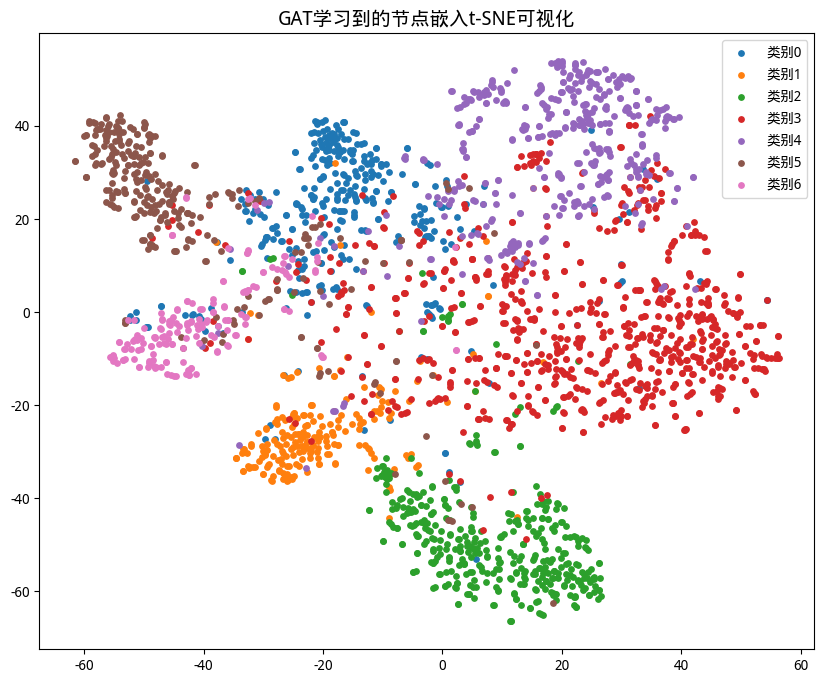

In [6]:
# 加载最优GAT模型
gat_model.load_state_dict(torch.load('./best_GAT.pth'))
gat_model.eval()

# 提取模型学习到的节点嵌入（第二层卷积前的特征）
with torch.no_grad():
    # 提取中间层特征
    x = gat_model.conv1(data.x, data.edge_index)
    node_embeddings = F.elu(x).cpu().numpy()
    labels = data.y.cpu().numpy()

# t-SNE降维到2维
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(node_embeddings)

# 绘制可视化图
plt.figure(figsize=(10, 8))
for i in range(dataset.num_classes):
    mask = labels == i
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], label=f'类别{i}', s=15)
plt.legend()
plt.title('GAT学习到的节点嵌入t-SNE可视化', fontsize=14)
plt.savefig('./gat_embedding_vis.png', dpi=300, bbox_inches='tight')
plt.show()

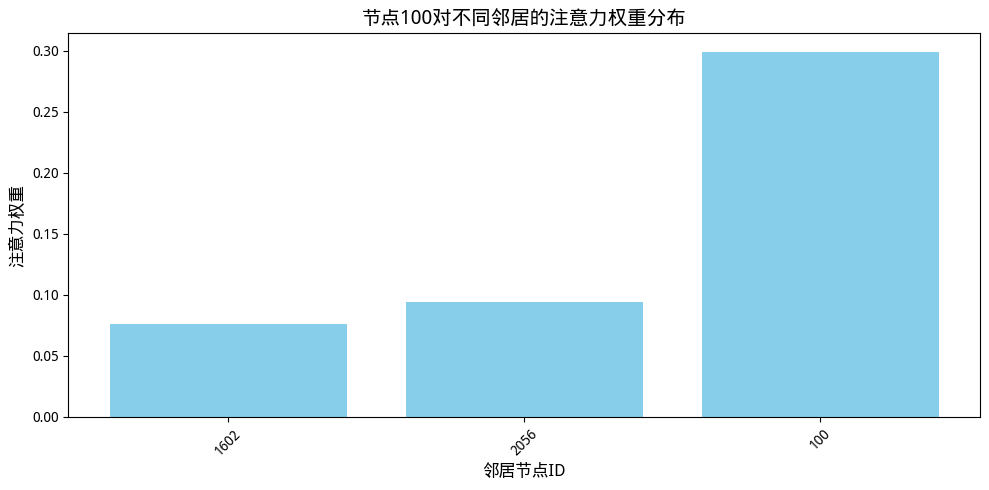

In [7]:
# 提取单个节点的注意力权重
with torch.no_grad():
    # 获取GAT第一层的注意力系数
    conv1 = gat_model.conv1
    out, attn_weight = conv1(data.x, data.edge_index, return_attention_weights=True)
    edge_index, alpha = attn_weight
    alpha = alpha.mean(dim=1).cpu().numpy()  # 平均多头注意力权重
    edge_index = edge_index.cpu().numpy()

# 选择目标节点（示例：节点100）
target_node = 100
# 找到该节点的所有邻居
neighbor_mask = edge_index[0] == target_node
neighbors = edge_index[1][neighbor_mask]
neighbor_attn = alpha[neighbor_mask]

# 绘制注意力权重分布
plt.figure(figsize=(10, 5))
plt.bar(range(len(neighbors)), neighbor_attn, color='skyblue')
plt.xlabel('邻居节点ID', fontsize=12)
plt.ylabel('注意力权重', fontsize=12)
plt.title(f'节点{target_node}对不同邻居的注意力权重分布', fontsize=14)
plt.xticks(range(len(neighbors)), neighbors, rotation=45)
plt.tight_layout()
plt.savefig('./gat_attention_vis.png', dpi=300)
plt.show()

In [8]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, GATConv

# ----------------------
# 1. 基础设置（固定随机种子）
# ----------------------
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 加载数据
dataset = Planetoid(root='./data/Cora', name='Cora')
data = dataset[0].to(device)

# ----------------------
# 2. GAT模型定义（关键修改1：强化Dropout）
# ----------------------
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads):
        super().__init__()
        # 【关键修改1】在GATConv内部添加dropout=0.6（论文核心设置）
        self.conv1 = GATConv(
            in_channels, hidden_channels,
            heads=heads,
            concat=True,
            dropout=0.6,  # 注意力权重的Dropout，防止过拟合
            add_self_loops=True
        )
        self.conv2 = GATConv(
            hidden_channels * heads, out_channels,
            heads=1,
            concat=False,
            dropout=0.6,
            add_self_loops=True
        )

    def forward(self, x, edge_index):
        # 【关键修改1】输入层先加Dropout，论文设置
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# ----------------------
# 3. 初始化与优化器（关键修改2：微调学习率+强化权重衰减）
# ----------------------
gat_model = GAT(
    in_channels=dataset.num_features,
    hidden_channels=8,
    out_channels=dataset.num_classes,
    heads=8
).to(device)

# 【关键修改2】学习率微调为0.003，权重衰减提升到1e-3，进一步防过拟合
gat_optimizer = torch.optim.Adam(
    gat_model.parameters(),
    lr=0.003,  # 从0.005微调至0.003，让训练更稳定
    weight_decay=1e-3  # 从5e-4提升到1e-3，强化L2正则化
)

# 可选：添加学习率调度器，让后期训练更精细
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(gat_optimizer, T_max=200, eta_min=1e-5)

# ----------------------
# 4. 训练函数（关键修改3：关闭早停，直接训练200轮）
# ----------------------
def train(model, optimizer, data):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test(model, data):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    train_acc = (pred[data.train_mask] == data.y[data.train_mask]).sum().item() / data.train_mask.sum().item()
    val_acc = (pred[data.val_mask] == data.y[data.val_mask]).sum().item() / data.val_mask.sum().item()
    test_acc = (pred[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()
    return train_acc, val_acc, test_acc

# ----------------------
# 5. 主训练循环（关键修改3：关闭早停，直接训练200轮）
# ----------------------
print("\n开始训练调整后的GAT模型...")
best_val_acc = 0
best_test_acc = 0
loss_history = []

for epoch in range(1, 201):  # 【关键修改3】直接训练200轮，不早停
    loss = train(gat_model, gat_optimizer, data)
    scheduler.step()  # 更新学习率
    loss_history.append(loss)
    train_acc, val_acc, test_acc = test(gat_model, data)

    # 只保存最优模型，不早停
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_test_acc = test_acc
        torch.save(gat_model.state_dict(), './best_gat_adjusted.pth')

    # 每20轮打印一次日志
    if epoch % 20 == 0:
        current_lr = gat_optimizer.param_groups[0]['lr']
        print(f'Epoch: {epoch:03d}, LR: {current_lr:.6f}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

print(f"\n调整后的GAT训练完成！最优验证集Acc: {best_val_acc:.4f}, 最优测试集Acc: {best_test_acc:.4f}")


开始训练调整后的GAT模型...
Epoch: 020, LR: 0.002927, Loss: 1.1508, Train Acc: 0.9429, Val Acc: 0.8020
Epoch: 040, LR: 0.002714, Loss: 0.8132, Train Acc: 0.9929, Val Acc: 0.8020
Epoch: 060, LR: 0.002384, Loss: 0.7475, Train Acc: 0.9929, Val Acc: 0.7980
Epoch: 080, LR: 0.001967, Loss: 0.6438, Train Acc: 1.0000, Val Acc: 0.7980
Epoch: 100, LR: 0.001505, Loss: 0.5857, Train Acc: 1.0000, Val Acc: 0.7980
Epoch: 120, LR: 0.001043, Loss: 0.5448, Train Acc: 1.0000, Val Acc: 0.8020
Epoch: 140, LR: 0.000626, Loss: 0.5594, Train Acc: 1.0000, Val Acc: 0.8020
Epoch: 160, LR: 0.000296, Loss: 0.3837, Train Acc: 1.0000, Val Acc: 0.7960
Epoch: 180, LR: 0.000083, Loss: 0.5488, Train Acc: 1.0000, Val Acc: 0.7980
Epoch: 200, LR: 0.000010, Loss: 0.4766, Train Acc: 1.0000, Val Acc: 0.7980

调整后的GAT训练完成！最优验证集Acc: 0.8080, 最优测试集Acc: 0.8250
